In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:

df = pd.read_csv("student-gabungan.csv")

In [3]:
print("Shape dataset:", df.shape)
print("\n5 data pertama:")
print(df.head())

Shape dataset: (1044, 34)

5 data pertama:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  freetime goout  Dalc  Walc  health absences  G1  G2  G3 mapel  
0        3     4     1     1       3        6   5   6   6  math  
1        3     3     1     1       3        4   5   5   6  math  
2        3     2     2     3       3       10   7   8  10  math  
3        2     2     1     1       5        2  15  14  15  math  
4        3     2     1     2       5        4   6  10  10  math  

[5 rows x 34 columns]


In [5]:
print("=== TIPE DATA ===")
print(df.dtypes)

=== TIPE DATA ===
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
mapel           str
dtype: object


In [7]:
print("\nJumlah kolom numerik:",
      len(df.select_dtypes(include='number').columns))

print("Jumlah kolom kategorikal:",
      len(df.select_dtypes(exclude='number').columns))


Jumlah kolom numerik: 16
Jumlah kolom kategorikal: 18


In [9]:
X = df.select_dtypes(include='number').drop(columns=['G3'])

print("Jumlah fitur untuk PCA:", X.shape[1])
print("\nFitur yang digunakan:")
print(X.columns.tolist())

Jumlah fitur untuk PCA: 15

Fitur yang digunakan:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape setelah standardisasi:", X_scaled.shape)

Shape setelah standardisasi: (1044, 15)


In [11]:
print("Mean tiap fitur:")
print(X_scaled.mean(axis=0).round(4))

print("\nStd tiap fitur:")
print(X_scaled.std(axis=0).round(4))

Mean tiap fitur:
[ 0. -0.  0.  0. -0. -0. -0. -0.  0.  0.  0. -0. -0. -0.  0.]

Std tiap fitur:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Shape setelah PCA:", X_pca.shape)

Shape setelah PCA: (1044, 15)


In [14]:
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_.round(4))


Explained Variance Ratio:
[0.1925 0.1295 0.0904 0.0861 0.0753 0.0664 0.0599 0.0584 0.0544 0.051
 0.0428 0.039  0.0241 0.0209 0.0093]


In [15]:
print("\nCumulative Explained Variance:")
print(pca.explained_variance_ratio_.cumsum().round(4))


Cumulative Explained Variance:
[0.1925 0.3219 0.4123 0.4984 0.5737 0.6401 0.7001 0.7585 0.8129 0.8638
 0.9066 0.9456 0.9698 0.9907 1.    ]


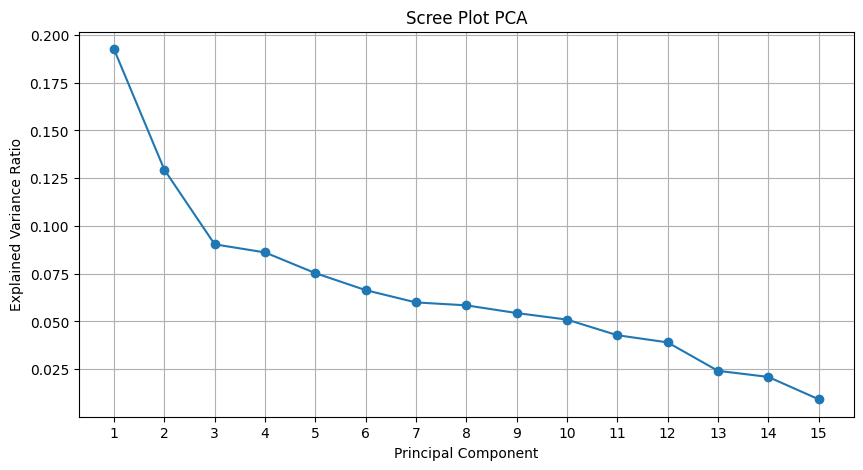

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot PCA")
plt.xticks(range(1, 16))
plt.grid()

plt.show()

In [18]:
pca_final = PCA(n_components=3)

X_pca_final = pca_final.fit_transform(X_scaled)

print("Shape sebelum PCA :", X_scaled.shape)
print("Shape setelah PCA :", X_pca_final.shape)

Shape sebelum PCA : (1044, 15)
Shape setelah PCA : (1044, 3)


In [20]:
print("=== Explained Variance Ratio ===")
print(pca_final.explained_variance_ratio_.round(4))

print("\n=== Cumulative Explained Variance ===")
print(pca_final.explained_variance_ratio_.cumsum().round(4))

=== Explained Variance Ratio ===
[0.1925 0.1295 0.0904]

=== Cumulative Explained Variance ===
[0.1925 0.3219 0.4123]


In [21]:
loading = pd.DataFrame(
    pca_final.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)

print("=== PCA LOADING ===")
print(loading.round(4))

=== PCA LOADING ===
               PC1     PC2     PC3
age        -0.2056 -0.0157 -0.0543
Medu        0.2682  0.3985  0.4075
Fedu        0.2424  0.4079  0.4151
traveltime -0.1825 -0.1286 -0.3104
studytime   0.2256 -0.1066 -0.0590
failures   -0.3416 -0.1021  0.1692
famrel      0.0423  0.0160 -0.1229
freetime   -0.1312  0.2409 -0.1889
goout      -0.2033  0.3740 -0.2242
Dalc       -0.2768  0.4068 -0.1723
Walc       -0.2893  0.4482 -0.1919
health     -0.0685  0.0844  0.0734
absences   -0.1154  0.1474  0.2298
G1          0.4420  0.1448 -0.3892
G2          0.4382  0.1478 -0.3912
